In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Scaler for Robust Scaling
from sklearn.preprocessing import RobustScaler

In [2]:
# Load the California Housing dataset

X, y = fetch_california_housing(
    return_X_y=True,
    as_frame=True
)

X.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


In [3]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1989,1.9750,52.0,2.800000,0.700000,193.0,4.825000,36.73,-119.79
256,2.2604,43.0,3.671480,1.184116,836.0,3.018051,37.77,-122.21
7887,6.2990,17.0,6.478022,1.087912,1387.0,3.810440,33.87,-118.04
4581,1.7199,17.0,2.518000,1.196000,3051.0,3.051000,34.06,-118.28
1993,2.2206,50.0,4.622754,1.161677,606.0,3.628743,36.73,-119.81


In [5]:
# Robust Scaling using RobustScaler

# Set up the scaler
scaler = RobustScaler().set_output(transform="pandas")

# Fit the scaler on the training data
scaler.fit(X_train)

# Transform the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1989,-0.722281,1.210526,-1.522730,-3.705368,-1.034043,2.354313,0.653439,-0.342105
256,-0.590487,0.736842,-0.976474,1.437770,-0.350000,0.236405,0.928571,-0.978947
7887,1.274486,-0.631579,0.782705,0.415726,0.236170,1.165156,-0.103175,0.118421
4581,-0.840083,-0.631579,-1.699491,1.564028,2.006383,0.275025,-0.052910,0.055263
1993,-0.608866,1.105263,-0.380202,1.199384,-0.594681,0.952191,0.653439,-0.347368
...,...,...,...,...,...,...,...,...
13123,0.403325,-0.473684,0.483074,-0.033129,-0.481915,0.509609,1.060847,-0.728947
19648,-0.288894,-0.105263,0.075196,-1.229874,-0.551064,0.327410,0.851852,-0.631579
9845,-0.157654,0.105263,-0.995441,-1.139981,-0.490426,-1.201400,0.613757,-0.897368
10799,0.966243,0.263158,-0.431699,0.162778,-0.120213,-0.666324,-0.169312,0.147368


In [7]:
scaler.center_

array([ 3.53910000e+00,  2.90000000e+01,  5.22931763e+00,  1.04878049e+00,
        1.16500000e+03,  2.81635506e+00,  3.42600000e+01, -1.18490000e+02])

In [8]:
scaler.scale_

array([2.16550000e+00, 1.90000000e+01, 1.59537022e+00, 9.41284380e-02,
       9.40000000e+02, 8.53176853e-01, 3.78000000e+00, 3.80000000e+00])

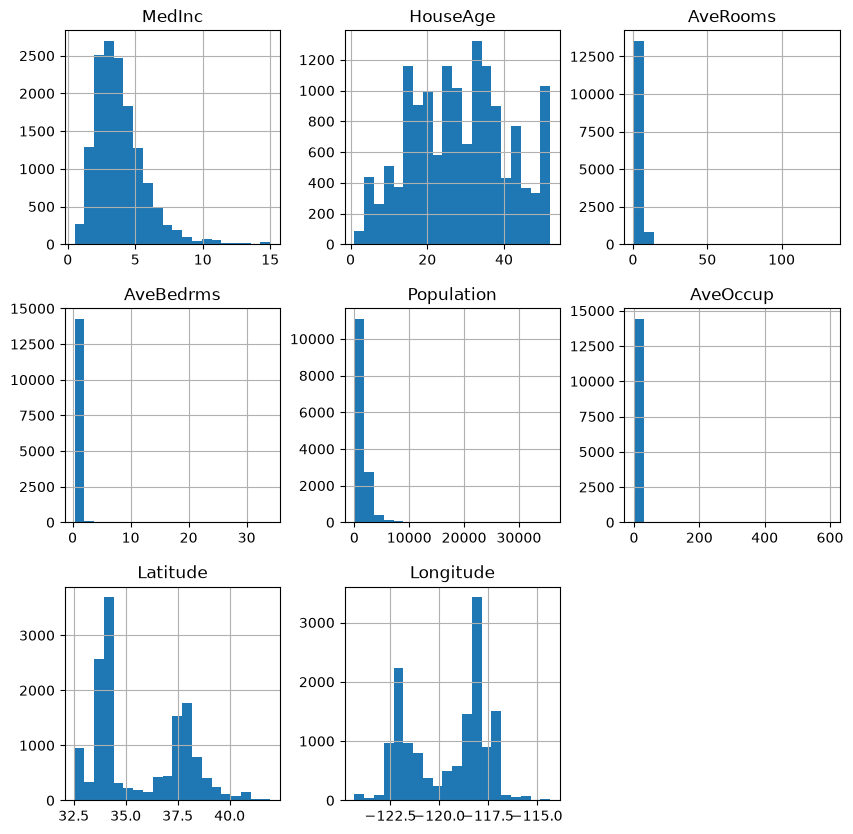

In [9]:
X_train.hist(bins=20, figsize=(10, 10))
plt.show()

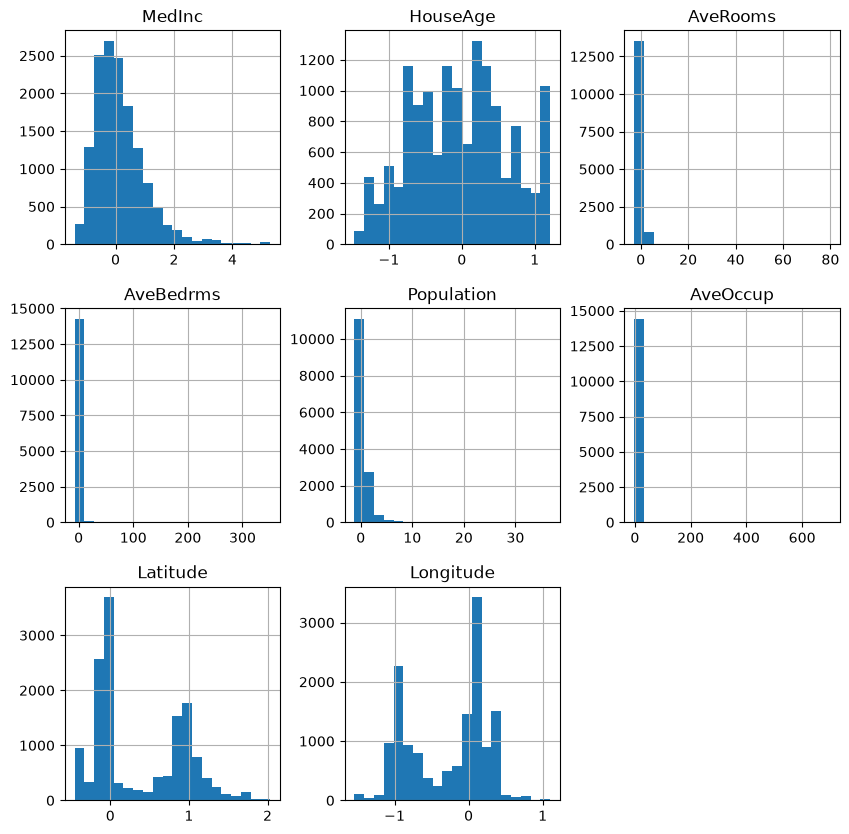

In [10]:
X_train_scaled.hist(bins=20, figsize=(10, 10))
plt.show()